# БЛОК 1. НАСТРОЙКА ОКРУЖЕНИЯ

In [1]:
# 1.1 ИМПОРТЫ БИБЛИОТЕК

# Системные и базовые
import os
import sys
import json
import shutil
import time
import warnings
import joblib
from datetime import datetime

# Данные и визуализация
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch  # ← для легенды в графиках

# Модели и предобработка
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Метрики (полный набор для универсальности)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay
)

# Калибровка (опционально, для проверки качества вероятностей)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Статистика
import scipy
from scipy import stats
from scipy.stats import norm
import statsmodels.api as sm

# Настройки
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

In [2]:
# 1.2 ОПРЕДЕЛЕНИЕ ОКРУЖЕНИЯ И ВЕРСИИ

# Определение окружения (Colab / Kaggle / локально)
try:
    from google.colab import drive
    IN_COLAB = True
    ENV_NAME = "Google Colab"
except ImportError:
    IN_COLAB = False
    # Проверка на Kaggle
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        ENV_NAME = "Kaggle"
    else:
        ENV_NAME = "Локально"

print(f"✓ {ENV_NAME}")

# Версии библиотек (для воспроизводимости)
print("\n📦 Версии:")
print(f"   Python: {sys.version.split()[0]}")
print(f"   pandas: {pd.__version__}")
print(f"   numpy: {np.__version__}")
print(f"   matplotlib: {mpl.__version__}")
print(f"   seaborn: {sns.__version__}")
print(f"   scipy: {scipy.__version__}")
print(f"   sklearn: {__import__('sklearn').__version__}")
print(f"   statsmodels: {sm.__version__}")

✓ Google Colab

📦 Версии:
   Python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2
   matplotlib: 3.10.0
   seaborn: 0.13.2
   scipy: 1.16.3
   sklearn: 1.6.1
   statsmodels: 0.14.6


In [3]:
# 1.3 НАСТРОЙКИ ПРОЕКТА

PROJECT_NAME = 'stroke'
BASE_PATH = '/content/drive/MyDrive/ml_learning'

# -----------------------------------------------------------------------------
# ПАРАМЕТРЫ МОДЕЛИ ПО УМОЛЧАНИЮ (логистическая регрессия)
# -----------------------------------------------------------------------------
DEFAULT_MODEL_PARAMS = {
    'class_weight': 'balanced',
    'random_state': 42,
    'max_iter': 1000,
    'solver': 'liblinear',
    'penalty': 'l2',
    'C': 1.0
}

THRESHOLDS = np.arange(0.1, 0.95, 0.05)

# -----------------------------------------------------------------------------
# КРИТЕРИИ ВЫБОРА ЛУЧШЕЙ МОДЕЛИ
# -----------------------------------------------------------------------------
SELECTION_PRIMARY_METRIC = 'auc_roc'
SELECTION_SECONDARY_METRIC = 'FN_05'
SELECTION_MIN_RECALL = 0.7
SELECTION_REQUIRE_STABLE = True
SELECTION_GAP_THRESHOLD = 0.03
SELECTION_WARNING_THRESHOLD = 0.05      # порог для 🟡 стабильности
FORCE_BEST_EXPERIMENT = None

# -----------------------------------------------------------------------------
# КРОСС-ВАЛИДАЦИЯ
# -----------------------------------------------------------------------------
CV_FOLDS = 5                            # количество фолдов (None = без CV)
CV_SCORING = 'roc_auc'                  # метрика для кросс-валидации

# -----------------------------------------------------------------------------
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# -----------------------------------------------------------------------------
SAVE_BEST_MODEL = True                  # сохранять лучшую модель (joblib)
SAVE_EXPERIMENTS_TABLE = True           # сохранять сводную таблицу экспериментов (CSV)
SAVE_PLOTS = True                       # сохранять графики в reports/plots/

# -----------------------------------------------------------------------------
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ПРИМЕНЕНИЯ ТРАНСФОРМАЦИЙ
# -----------------------------------------------------------------------------
def apply_transforms(X_tr, X_val, transform_rules):
    """
    Применяет трансформации к данным по правилам.

    transform_rules: dict с ключами:
        - 'drop': список колонок для удаления
        - 'poly': dict {колонка: степень}
        - 'interaction': список кортежей [(кол1, кол2), ...]
    """
    if transform_rules is None:
        return X_tr.copy(), X_val.copy()

    # Проверка на конфликты между drop и poly
    if 'drop' in transform_rules and 'poly' in transform_rules:
        dropped = set(transform_rules['drop'])
        poly_cols = set(transform_rules['poly'].keys())
        conflict = dropped & poly_cols
        if conflict:
            warnings.warn(f"⚠️ Колонки {conflict} есть и в 'drop', и в 'poly'. Они будут удалены.")

    X_tr_new = X_tr.copy()
    X_val_new = X_val.copy()

    # 1. Удаление колонок
    if 'drop' in transform_rules:
        cols = transform_rules['drop']
        X_tr_new = X_tr_new.drop(columns=[c for c in cols if c in X_tr_new.columns])
        X_val_new = X_val_new.drop(columns=[c for c in cols if c in X_val_new.columns])

    # 2. Полиномы
    if 'poly' in transform_rules:
        for col, degree in transform_rules['poly'].items():
            if col in X_tr_new.columns:
                for d in range(2, degree + 1):
                    X_tr_new[f'{col}^{d}'] = X_tr_new[col] ** d
                    X_val_new[f'{col}^{d}'] = X_val_new[col] ** d

    # 3. Взаимодействия
    if 'interaction' in transform_rules:
        for col1, col2 in transform_rules['interaction']:
            if col1 in X_tr_new.columns and col2 in X_tr_new.columns:
                name = f'{col1}_x_{col2}'
                X_tr_new[name] = X_tr_new[col1] * X_tr_new[col2]
                X_val_new[name] = X_val_new[col1] * X_val_new[col2]

    return X_tr_new, X_val_new

# -----------------------------------------------------------------------------
# СПИСОК ЭКСПЕРИМЕНТОВ
# Формат: (название, изменения параметров, правила трансформации или None, cv_folds или None)
# -----------------------------------------------------------------------------
EXPERIMENTS_TO_RUN = [
    ("Baseline", {}, None, None),
    ("Baseline + CV", {}, None, CV_FOLDS),  # с кросс-валидацией
    ("Без балансировки", {'class_weight': None}, None, None),
    ("C=0.1", {'C': 0.1}, None, None),
    ("C=10.0", {'C': 10.0}, None, None),
    ("L1 регуляризация", {'penalty': 'l1', 'solver': 'saga'}, None, None),

    # Удаление признаков
    ("Без marriage_risk", {}, {'drop': ['marriage_risk_senior_married', 'marriage_risk_senior_unmarried']}, None),

    # Полиномы
    ("+ age²", {}, {'poly': {'age': 2}}, None),
    ("Без marriage_risk + age²", {}, {'drop': ['marriage_risk_senior_married', 'marriage_risk_senior_unmarried'], 'poly': {'age': 2}}, None),

    # Взаимодействия
    ("+ age × glucose", {}, {'interaction': [('age', 'avg_glucose_level')]}, None),
    ("+ age × bmi", {}, {'interaction': [('age', 'bmi')]}, None),
]

# -----------------------------------------------------------------------------
# КОЛОНКИ ДЛЯ ОТОБРАЖЕНИЯ В СВОДНОЙ ТАБЛИЦЕ
# -----------------------------------------------------------------------------
DISPLAY_COLUMNS = [
    'experiment',
    'auc_roc',
    'gap_auc',
    'stability',
    'auc_pr',
    'best_f1',
    'best_threshold_f1',
    'youden_threshold',
    'recall_05',
    'precision_05',
    'f1_05',
    'mcc_05',
    'FN_05',
    'FP_05',
]
# -----------------------------------------------------------------------------
# ВЫВОД НАСТРОЕК
# -----------------------------------------------------------------------------
print("=" * 60)
print(f"📁 PROJECT: {PROJECT_NAME}")
print(f"📂 BASE_PATH: {BASE_PATH}")
print(f"🧪 Экспериментов: {len(EXPERIMENTS_TO_RUN)}")

print(f"\n🎯 КРИТЕРИИ ВЫБОРА:")
print(f"   Основная метрика: {SELECTION_PRIMARY_METRIC}")
print(f"   Вторичная метрика: {SELECTION_SECONDARY_METRIC}")
print(f"   Мин. Recall: {SELECTION_MIN_RECALL}")
print(f"   Стабильность: {'✅ требуется' if SELECTION_REQUIRE_STABLE else '❌ не требуется'} (gap < {SELECTION_GAP_THRESHOLD})")
print(f"   Принудительно: {FORCE_BEST_EXPERIMENT if FORCE_BEST_EXPERIMENT else 'авто'}")

print(f"\n🔄 КРОСС-ВАЛИДАЦИЯ:")
print(f"   Фолды: {CV_FOLDS if CV_FOLDS else 'отключена'}")
print(f"   Метрика: {CV_SCORING}")

print(f"\n🔧 ПАРАМЕТРЫ МОДЕЛИ ПО УМОЛЧАНИЮ:")
for k, v in DEFAULT_MODEL_PARAMS.items():
    print(f"   {k}: {v}")

print(f"\n💾 СОХРАНЕНИЕ:")
print(f"   Модель: {'✅' if SAVE_BEST_MODEL else '❌'}")
print(f"   Таблица экспериментов: {'✅' if SAVE_EXPERIMENTS_TABLE else '❌'}")
print(f"   Графики: {'✅' if SAVE_PLOTS else '❌'}")
print("=" * 60 + "\n")

📁 PROJECT: stroke
📂 BASE_PATH: /content/drive/MyDrive/ml_learning
🧪 Экспериментов: 11

🎯 КРИТЕРИИ ВЫБОРА:
   Основная метрика: auc_roc
   Вторичная метрика: FN_05
   Мин. Recall: 0.7
   Стабильность: ✅ требуется (gap < 0.03)
   Принудительно: авто

🔄 КРОСС-ВАЛИДАЦИЯ:
   Фолды: 5
   Метрика: roc_auc

🔧 ПАРАМЕТРЫ МОДЕЛИ ПО УМОЛЧАНИЮ:
   class_weight: balanced
   random_state: 42
   max_iter: 1000
   solver: liblinear
   penalty: l2
   C: 1.0

💾 СОХРАНЕНИЕ:
   Модель: ✅
   Таблица экспериментов: ✅
   Графики: ✅



In [4]:
# 1.4 НАСТРОЙКА ПУТЕЙ

PROJECT_PATH = os.path.join(BASE_PATH, 'datasets', PROJECT_NAME)
SPLITS_PATH = os.path.join(PROJECT_PATH, 'splits')
MODELS_PATH = os.path.join(PROJECT_PATH, 'models')
REPORTS_PATH = os.path.join(PROJECT_PATH, 'reports')
PLOTS_PATH = os.path.join(REPORTS_PATH, 'plots')

# Проверка существования обязательных папок (должны быть созданы в Preprocessing/EDA)
for path, source in [
    (SPLITS_PATH, "Preprocessing/EDA"),
    (REPORTS_PATH, "Preprocessing/EDA"),
    (PLOTS_PATH, "EDA")
]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Папка {path} не найдена.\n"
            f"   Сначала выполните ноутбук {source} для проекта '{PROJECT_NAME}'."
        )

# Создание папки для моделей (специфична для Modeling)
os.makedirs(MODELS_PATH, exist_ok=True)

print("📂 ПУТИ ПРОЕКТА:")
print(f"   PROJECT_PATH: {PROJECT_PATH}")
print(f"   SPLITS_PATH:  {SPLITS_PATH} ✓")
print(f"   MODELS_PATH:  {MODELS_PATH} (создана)")
print(f"   REPORTS_PATH: {REPORTS_PATH} ✓")
print(f"   PLOTS_PATH:   {PLOTS_PATH} ✓")
print("✓ Все пути настроены\n")

📂 ПУТИ ПРОЕКТА:
   PROJECT_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke
   SPLITS_PATH:  /content/drive/MyDrive/ml_learning/datasets/stroke/splits ✓
   MODELS_PATH:  /content/drive/MyDrive/ml_learning/datasets/stroke/models (создана)
   REPORTS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/reports ✓
   PLOTS_PATH:   /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots ✓
✓ Все пути настроены



In [5]:
# 1.5 МОНТИРОВАНИЕ GOOGLE DRIVE

if IN_COLAB:
    if BASE_PATH.startswith('/content/drive'):
        if os.path.ismount('/content/drive'):
            print("✓ Google Drive уже смонтирован")
        else:
            print("📂 Монтирование Google Drive...")
            if os.path.exists('/content/drive'):
                shutil.rmtree('/content/drive')
            drive.mount('/content/drive')
            print("✓ Google Drive смонтирован")
else:
    print("✓ Локальная среда, монтирование не требуется")

print()

✓ Google Drive уже смонтирован



In [6]:
# 1.6 ЗАГРУЗКА МЕТАДАННЫХ

metadata_path = os.path.join(PROJECT_PATH, 'production_metadata.json')

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"❌ Файл не найден: {metadata_path}\n"
        f"   Убедитесь, что ноутбук EDA выполнен для проекта '{PROJECT_NAME}'."
    )

with open(metadata_path, 'r', encoding='utf-8') as f:
    prod_metadata = json.load(f)

TARGET_COLUMN = prod_metadata['target_column']
TASK_TYPE = prod_metadata['task_type']
FEATURE_COLUMNS = prod_metadata['features']['all_features']
FINAL_COUNT = prod_metadata['features']['final_count']

# Проверка типа задачи
if TASK_TYPE != 'classification':
    raise ValueError(
        f"❌ Этот ноутбук предназначен для классификации.\n"
        f"   Обнаружен тип задачи: '{TASK_TYPE}'.\n"
        f"   Используйте соответствующий шаблон."
    )

# Проверка наличия признаков
if FINAL_COUNT == 0:
    raise ValueError("❌ Список признаков пуст. Проверьте ноутбук EDA.")

print("📋 МЕТАДАННЫЕ ПРОЕКТА:")
print(f"   Целевая переменная: {TARGET_COLUMN}")
print(f"   Тип задачи: {TASK_TYPE}")
print(f"   Признаков: {FINAL_COUNT}")
print(f"   Список признаков:")
for i, col in enumerate(FEATURE_COLUMNS, 1):
    print(f"      {i:2d}. {col}")
print()

📋 МЕТАДАННЫЕ ПРОЕКТА:
   Целевая переменная: stroke
   Тип задачи: classification
   Признаков: 6
   Список признаков:
       1. age
       2. avg_glucose_level
       3. bmi
       4. cardio_risk
       5. marriage_risk_senior_married
       6. marriage_risk_senior_unmarried



In [7]:
# 1.7 ЗАГРУЗКА ДАННЫХ

# Проверка наличия файлов (должны быть созданы в EDA)
train_path = os.path.join(SPLITS_PATH, 'X_train_scaled.csv')
y_train_path = os.path.join(SPLITS_PATH, 'y_train.csv')
val_X_path = os.path.join(SPLITS_PATH, 'X_val_final.csv')
val_y_path = os.path.join(SPLITS_PATH, 'y_val_final.csv')
test_X_path = os.path.join(SPLITS_PATH, 'X_test_final.csv')
test_y_path = os.path.join(SPLITS_PATH, 'y_test_final.csv')

missing = []
for p, name in [
    (train_path, 'X_train_scaled.csv'),
    (y_train_path, 'y_train.csv'),
    (val_X_path, 'X_val_final.csv'),
    (val_y_path, 'y_val_final.csv'),
    (test_X_path, 'X_test_final.csv'),
    (test_y_path, 'y_test_final.csv')
]:
    if not os.path.exists(p):
        missing.append(name)

if missing:
    raise FileNotFoundError(
        f"❌ Не найдены файлы в {SPLITS_PATH}:\n"
        f"   {', '.join(missing)}\n"
        f"   Убедитесь, что ноутбук EDA выполнен для проекта '{PROJECT_NAME}'."
    )

# Загрузка
X_train = pd.read_csv(train_path)
y_train = pd.read_csv(y_train_path).iloc[:, 0]
X_val = pd.read_csv(val_X_path)
y_val = pd.read_csv(val_y_path).iloc[:, 0]
X_test = pd.read_csv(test_X_path)
y_test = pd.read_csv(test_y_path).iloc[:, 0]

print("ДАННЫЕ ЗАГРУЖЕНЫ:")
print(f"   Train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   Val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"   Test:  {X_test.shape} | y_test:  {y_test.shape}")
print()

ДАННЫЕ ЗАГРУЖЕНЫ:
   Train: (2911, 6) | y_train: (2911,)
   Val:   (971, 6) | y_val:   (971,)
   Test:  (971, 6) | y_test:  (971,)



In [8]:
# 1.8 ПРОВЕРКА СООТВЕТСТВИЯ ПРИЗНАКОВ И БАЛАНСА КЛАССОВ

# Проверка соответствия признаков
train_cols = set(X_train.columns)
meta_cols = set(FEATURE_COLUMNS)

if train_cols == meta_cols:
    print("✓ Состав признаков соответствует метаданным")
else:
    missing_in_data = meta_cols - train_cols
    extra_in_data = train_cols - meta_cols
    print("❌ НЕСООТВЕТСТВИЕ ПРИЗНАКОВ:")
    if missing_in_data:
        print(f"   В метаданных, но не в данных: {missing_in_data}")
    if extra_in_data:
        print(f"   В данных, но не в метаданных: {extra_in_data}")
    raise ValueError("Состав признаков не соответствует production_metadata.json. Проверьте EDA.")

# Проверка пропусков
nulls_train = X_train.isnull().sum().sum()
nulls_val = X_val.isnull().sum().sum()
nulls_test = X_test.isnull().sum().sum()

if nulls_train + nulls_val + nulls_test == 0:
    print("✓ Пропусков нет (train/val/test)")
else:
    print(f"⚠️ Обнаружены пропуски: train={nulls_train}, val={nulls_val}, test={nulls_test}")

# Баланс классов
def print_class_balance(y, name):
    counts = y.value_counts()
    print(f"\n📊 Баланс классов в {name}:")
    for cls, count in counts.items():
        print(f"   Класс {cls}: {count} ({count/len(y)*100:.1f}%)")
    print(f"   Соотношение: {counts.max() / counts.min():.1f}:1")

print_class_balance(y_train, "TRAIN")
print_class_balance(y_val, "VAL")
print_class_balance(y_test, "TEST")
print()

✓ Состав признаков соответствует метаданным
✓ Пропусков нет (train/val/test)

📊 Баланс классов в TRAIN:
   Класс 0: 2786 (95.7%)
   Класс 1: 125 (4.3%)
   Соотношение: 22.3:1

📊 Баланс классов в VAL:
   Класс 0: 929 (95.7%)
   Класс 1: 42 (4.3%)
   Соотношение: 22.1:1

📊 Баланс классов в TEST:
   Класс 0: 929 (95.7%)
   Класс 1: 42 (4.3%)
   Соотношение: 22.1:1



# БЛОК 2. ФУНКЦИИ ДЛЯ ЭКСПЕРИМЕНТОВ

In [9]:
# 2.1 УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ЗАПУСКА ЭКСПЕРИМЕНТА

def run_experiment(model, experiment_name, X_train, y_train, X_val, y_val,
                   thresholds=THRESHOLDS, cv=None):
    """
    Унифицированный запуск одного эксперимента.

    Parameters:
    -----------
    model : sklearn-совместимая модель с predict_proba()
    experiment_name : str
    X_train, y_train, X_val, y_val : DataFrame/Series
    thresholds : array-like
    cv : int или None
        Количество фолдов для кросс-валидации на train (опционально)

    Returns:
    --------
    df_thresholds : DataFrame с метриками при разных порогах
    summary : dict со сводными метриками
    model : обученная модель
    """

    # Проверка поддержки predict_proba
    if not hasattr(model, 'predict_proba'):
        raise TypeError(
            f"❌ Модель {type(model).__name__} не поддерживает predict_proba().\n"
            f"   Используйте классификатор с вероятностными предсказаниями."
        )

    start_time = time.time()

    # Обучение
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Предсказания
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # Метрики на train (для оценки переобучения)
    train_auc = roc_auc_score(y_train, y_train_proba)

    # Основные метрики на val (не зависящие от порога)
    auc_roc = roc_auc_score(y_val, y_val_proba)
    auc_pr = average_precision_score(y_val, y_val_proba)
    brier = brier_score_loss(y_val, y_val_proba)
    logloss = log_loss(y_val, y_val_proba)
    gap_auc = train_auc - auc_roc

    # Кросс-валидация (опционально)
    cv_auc_mean, cv_auc_std = None, None
    if cv is not None:
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
        cv_auc_mean = cv_scores.mean()
        cv_auc_std = cv_scores.std()

    # Расчёт метрик при всех порогах
    results = []
    for thresh in thresholds:
        y_pred = (y_val_proba >= thresh).astype(int)

        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        mcc = matthews_corrcoef(y_val, y_pred)

        cm = confusion_matrix(y_val, y_pred)
        TN, FP, FN, TP = cm.ravel()

        results.append({
            'threshold': thresh,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'mcc': mcc,
            'TP': TP,
            'FN': FN,
            'FP': FP,
            'TN': TN,
            'pred_positives': TP + FP
        })

    df_thresholds = pd.DataFrame(results)

    # Поиск оптимального порога по F1
    best_f1_idx = df_thresholds['f1'].idxmax()
    best_row = df_thresholds.loc[best_f1_idx]

    # Поиск оптимального порога по Youden's J
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_val_proba)
    youden_idx = np.argmax(tpr - fpr)
    youden_threshold = roc_thresholds[youden_idx] if youden_idx < len(roc_thresholds) else 0.5

    # Метрики при пороге Youden (ближайший из проверенных)
    youden_row_idx = (df_thresholds['threshold'] - youden_threshold).abs().idxmin()
    youden_row = df_thresholds.loc[youden_row_idx]

    # Метрики при пороге 0.5
    at_05 = df_thresholds[df_thresholds['threshold'] == 0.5]
    if len(at_05) > 0:
        at_05 = at_05.iloc[0]
    else:
        closest_idx = (df_thresholds['threshold'] - 0.5).abs().idxmin()
        at_05 = df_thresholds.loc[closest_idx]

    # Сводка
    summary = {
        'experiment': experiment_name,
        'train_time': train_time,
        'train_auc': train_auc,
        'auc_roc': auc_roc,
        'gap_auc': gap_auc,
        'auc_pr': auc_pr,
        'brier': brier,
        'logloss': logloss,
        'best_threshold_f1': best_row['threshold'],
        'best_f1': best_row['f1'],
        'best_recall': best_row['recall'],
        'best_precision': best_row['precision'],
        'best_mcc': best_row['mcc'],
        'youden_threshold': youden_threshold,
        'youden_recall': youden_row['recall'],
        'youden_precision': youden_row['precision'],
        'youden_f1': youden_row['f1'],
        'youden_FN': youden_row['FN'],
        'youden_FP': youden_row['FP'],
        'recall_05': at_05['recall'],
        'precision_05': at_05['precision'],
        'f1_05': at_05['f1'],
        'mcc_05': at_05['mcc'],
        'FN_05': at_05['FN'],
        'FP_05': at_05['FP'],
        'TP_05': at_05['TP'],
        'TN_05': at_05['TN'],
        'params': str(model.get_params())
    }

    # Добавляем CV метрики, если были рассчитаны
    if cv is not None:
        summary['cv_auc_mean'] = cv_auc_mean
        summary['cv_auc_std'] = cv_auc_std

    return df_thresholds, summary, model

In [10]:
# 2.2 ФУНКЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ

def compare_models(summaries_list, primary_metric='auc_roc', min_recall=0.0,
                   gap_threshold=0.03, warning_threshold=0.05):
    """
    Создаёт сводную таблицу сравнения всех экспериментов с оценкой стабильности.
    Возвращает ПОЛНЫЙ DataFrame со всеми метриками.

    Параметры:
    ----------
    summaries_list : list
        Список словарей summary из функции run_experiment()
    primary_metric : str
        Метрика для сортировки
    min_recall : float
        Минимальный Recall для фильтрации (0.0 = без фильтрации)
    gap_threshold : float
        Порог для определения переобучения — ✅ стабильна
    warning_threshold : float
        Порог для 🟡 умеренного переобучения

    Возвращает:
    -----------
    DataFrame с отсортированными результатами (ВСЕ колонки)
    """

    if not summaries_list:
        print("❌ Список экспериментов пуст.")
        return pd.DataFrame()

    df = pd.DataFrame(summaries_list)

    # Оценка стабильности (если есть train_auc)
    if 'train_auc' in df.columns:
        df['gap_auc'] = df['train_auc'] - df['auc_roc']
        df['stability'] = df['gap_auc'].apply(
            lambda x: '✅' if abs(x) <= gap_threshold else ('🟡' if abs(x) <= warning_threshold else '🔴')
        )
    else:
        df['gap_auc'] = 0.0
        df['stability'] = '✅'

    # Вывод статистики по стабильности
    stable_count = (df['stability'] == '✅').sum()
    warning_count = (df['stability'] == '🟡').sum()
    unstable_count = (df['stability'] == '🔴').sum()
    print(f"Стабильность: ✅ {stable_count} | 🟡 {warning_count} | 🔴 {unstable_count}")

    # Фильтрация по минимальному Recall
    if min_recall > 0:
        before = len(df)
        df = df[df['recall_05'] >= min_recall].copy()
        if len(df) == 0:
            print(f"⚠️ Нет моделей с Recall >= {min_recall}")
            return pd.DataFrame()
        print(f"Отфильтровано по Recall >= {min_recall}: {before} → {len(df)} экспериментов")

    # Сортировка
    ascending = False if primary_metric != 'logloss' else True
    df = df.sort_values(primary_metric, ascending=ascending)

    # Возвращаем ПОЛНЫЙ DataFrame (без фильтрации колонок)
    return df

In [11]:
# 2.3 ФУНКЦИЯ ВЫБОРА ЛУЧШЕЙ МОДЕЛИ

def select_best_model(comparison_df, primary_metric='auc_roc', secondary_metric='FN_05',
                      min_recall=0.7, require_stable=True, force_experiment=None):
    """
    Автоматически выбирает лучшую модель с учётом стабильности и возможности принудительного выбора.

    Параметры:
    ----------
    comparison_df : DataFrame
        Таблица сравнения из compare_models()
    primary_metric : str
        Основная метрика для сортировки
    secondary_metric : str
        Вторичная метрика
    min_recall : float
        Минимальный Recall
    require_stable : bool
        Требовать стабильность (✅)
    force_experiment : str или None
        Принудительно выбрать эксперимент по имени

    Возвращает:
    -----------
    best_row : Series (строка с лучшей моделью)
    best_idx : индекс в comparison_df
    """

    if comparison_df.empty:
        print("❌ Нет моделей для выбора.")
        return None, None

    df = comparison_df.copy()

    # -------------------------------------------------------------------------
    # 1. ПРИНУДИТЕЛЬНЫЙ ВЫБОР
    # -------------------------------------------------------------------------
    if force_experiment is not None:
        forced = df[df['experiment'] == force_experiment]
        if len(forced) > 0:
            best = forced.iloc[0]
            best_idx = forced.index[0]
            print("=" * 60)
            print("🔧 ПРИНУДИТЕЛЬНЫЙ ВЫБОР МОДЕЛИ")
            print("=" * 60)
            print(f"⚠️ Выбрана: {best['experiment']} (принудительно)")
            print(f"   ROC-AUC: {best['auc_roc']:.4f} | Recall@0.5: {best['recall_05']:.4f} | FN: {best['FN_05']:.0f}")
            print(f"   Стабильность: {best.get('stability', '?')} (gap_auc = {best.get('gap_auc', 0):.4f})")
            print("=" * 60)
            return best, best_idx
        else:
            print(f"⚠️ Эксперимент '{force_experiment}' не найден. Перехожу к автовыбору.\n")

    # -------------------------------------------------------------------------
    # 2. АВТОМАТИЧЕСКИЙ ВЫБОР
    # -------------------------------------------------------------------------
    # Фильтр по стабильности
    if require_stable and 'stability' in df.columns:
        df_stable = df[df['stability'] == '✅'].copy()
        if len(df_stable) == 0:
            print(f"⚠️ Нет стабильных моделей (stability != ✅)")
            print("   Расширяем поиск на 🟡 модели...")
            df = df[df['stability'].isin(['✅', '🟡'])].copy()
        else:
            df = df_stable
            print(f"✓ Отфильтровано стабильных моделей: {len(df)}")

    # Фильтр по Recall
    valid = df[df['recall_05'] >= min_recall]

    if len(valid) == 0:
        print(f"⚠️ Нет моделей с Recall >= {min_recall}")
        best = df.loc[df['recall_05'].idxmax()]
        best_idx = df['recall_05'].idxmax()
    else:
        ascending_secondary = True if secondary_metric in ['FN_05', 'FP_05', 'logloss'] else False
        valid = valid.sort_values([primary_metric, secondary_metric], ascending=[False, ascending_secondary])
        best = valid.iloc[0]
        best_idx = valid.index[0]

    print("=" * 60)
    print("🏆 АВТОМАТИЧЕСКИЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
    print("=" * 60)
    print(f"Первичная: {primary_metric} | Вторичная: {secondary_metric} | Мин. Recall: {min_recall}")
    print(f"Требовать стабильность: {require_stable}")
    print()
    print(f"✅ Выбрана: {best['experiment']}")
    print(f"   ROC-AUC: {best['auc_roc']:.4f} | Recall@0.5: {best['recall_05']:.4f} | FN: {best['FN_05']:.0f}")
    print(f"   Стабильность: {best.get('stability', '?')} (gap_auc = {best.get('gap_auc', 0):.4f})")
    print("=" * 60)

    return best, best_idx

In [12]:
# 2.4 ФУНКЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ СРАВНЕНИЯ ЭКСПЕРИМЕНТОВ

def plot_experiments_comparison(comparison_df, save_path=None):
    """
    Визуализирует сравнение всех экспериментов.

    Параметры:
    ----------
    comparison_df : DataFrame
        Таблица сравнения из compare_models()
    save_path : str, optional
        Путь для сохранения графика
    """

    df = comparison_df.copy()

    # Проверка наличия обязательных колонок
    required_cols = ['recall_05', 'auc_roc', 'FP_05', 'FN_05', 'precision_05', 'experiment']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"⚠️ Нет обязательных колонок для графиков: {missing}")
        return

    # Цвета по стабильности (если есть колонка stability)
    if 'stability' in df.columns:
        color_map = {'✅': '#2ecc71', '🟡': '#f1c40f', '🔴': '#e74c3c'}
        df['color'] = df['stability'].map(color_map).fillna('#3498db')
    else:
        df['color'] = '#3498db'

    # Функция для короткого имени
    def shorten_name(name, max_len=15):
        if len(name) <= max_len:
            return name
        words = name.split()
        if len(words) == 1:
            return name[:max_len-2] + '..'
        result = words[0]
        for w in words[1:]:
            if len(result + ' ' + w) <= max_len:
                result += ' ' + w
            else:
                break
        return result + ('..' if len(result) < len(name) else '')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # График 1: ROC-AUC vs Recall@0.5
    ax1 = axes[0]
    for _, row in df.iterrows():
        ax1.scatter(row['recall_05'], row['auc_roc'], s=100, alpha=0.7, c=row['color'])
        short_name = shorten_name(row['experiment'])
        ax1.annotate(short_name, (row['recall_05'], row['auc_roc']),
                     fontsize=9, ha='center', va='bottom')

    ax1.set_xlabel('Recall @ 0.5')
    ax1.set_ylabel('ROC-AUC')
    ax1.set_title('ROC-AUC vs Recall')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0.5, 1)

    # График 2: FN vs FP
    ax2 = axes[1]
    for _, row in df.iterrows():
        ax2.scatter(row['FP_05'], row['FN_05'], s=100, alpha=0.7, c=row['color'])
        short_name = shorten_name(row['experiment'])
        ax2.annotate(short_name, (row['FP_05'], row['FN_05']),
                     fontsize=9, ha='center', va='bottom')

    ax2.set_xlabel('FP (ложные тревоги)')
    ax2.set_ylabel('FN (пропущенные инсульты)')
    ax2.set_title('Ошибки модели')
    ax2.grid(True, alpha=0.3)

    # Добавляем стрелку в "идеальный" угол (0,0)
    ax2.annotate('ИДЕАЛ', xy=(0, 0), xytext=(max(df['FP_05'])*0.1, max(df['FN_05'])*0.1),
                 arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

    # График 3: Precision vs Recall
    ax3 = axes[2]
    for _, row in df.iterrows():
        ax3.scatter(row['recall_05'], row['precision_05'], s=100, alpha=0.7, c=row['color'])
        short_name = shorten_name(row['experiment'])
        ax3.annotate(short_name, (row['recall_05'], row['precision_05']),
                     fontsize=9, ha='center', va='bottom')

    ax3.set_xlabel('Recall @ 0.5')
    ax3.set_ylabel('Precision @ 0.5')
    ax3.set_title('Precision vs Recall')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, max(df['precision_05']) * 1.1 if max(df['precision_05']) > 0 else 0.5)

    # Легенда для стабильности
    if 'stability' in df.columns:
        legend_elements = [
            Patch(facecolor='#2ecc71', label='✅ Стабильна (gap ≤ 0.03)'),
            Patch(facecolor='#f1c40f', label='🟡 Умеренная (gap ≤ 0.05)'),
            Patch(facecolor='#e74c3c', label='🔴 Нестабильна (gap > 0.05)'),
        ]
        fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 0.9))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ График сохранён: {save_path}")

    plt.show()

    # Автоматические выводы
    print("\n" + "="*60)
    print("📊 АВТОМАТИЧЕСКИЕ ВЫВОДЫ ПО СРАВНЕНИЮ")
    print("="*60)

    best_auc = df.loc[df['auc_roc'].idxmax()]
    best_recall = df.loc[df['recall_05'].idxmax()]
    best_f1 = df.loc[df['f1_05'].idxmax()]
    best_precision = df.loc[df['precision_05'].idxmax()]

    print(f"🏆 Лучшая ROC-AUC: {best_auc['experiment']} (AUC={best_auc['auc_roc']:.4f})")
    print(f"🏆 Лучший Recall: {best_recall['experiment']} (Recall={best_recall['recall_05']:.4f}, FN={best_recall['FN_05']:.0f})")
    print(f"🏆 Лучший F1: {best_f1['experiment']} (F1={best_f1['f1_05']:.4f})")
    print(f"🏆 Лучшая Precision: {best_precision['experiment']} (Precision={best_precision['precision_05']:.4f})")
    print("="*60)

# БЛОК 3. ЗАПУСК ЭКСПЕРИМЕНТОВ

In [13]:
# 3.1 АВТОМАТИЧЕСКИЙ ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ

all_summaries = []
all_thresholds = {}
all_models = {}

for exp_name, param_changes, transform_rules, cv_folds in EXPERIMENTS_TO_RUN:
    print(f"\n🔄 {exp_name}...")

    # Применяем трансформации
    X_train_exp, X_val_exp = apply_transforms(X_train, X_val, transform_rules)

    # Проверка, что остались признаки
    if X_train_exp.shape[1] == 0:
        print(f"   ⚠️ Пропуск: не осталось признаков после трансформаций")
        continue

    # Создание модели с изменёнными параметрами
    params = DEFAULT_MODEL_PARAMS.copy()
    params.update(param_changes)
    model = LogisticRegression(**params)

    # Запуск эксперимента
    df_thresh, summary, trained_model = run_experiment(
        model, exp_name,
        X_train_exp, y_train,
        X_val_exp, y_val,
        thresholds=THRESHOLDS,
        cv=cv_folds
    )

    all_summaries.append(summary)
    all_thresholds[exp_name] = df_thresh
    all_models[exp_name] = trained_model

    # Вывод результатов
    cv_info = ""
    if cv_folds:
        cv_info = f" | CV-AUC: {summary.get('cv_auc_mean', 0):.4f} ± {summary.get('cv_auc_std', 0):.4f}"
    print(f"   ✓ ROC-AUC: {summary['auc_roc']:.4f} | Recall@0.5: {summary['recall_05']:.4f} | FN@0.5: {summary['FN_05']:.0f}{cv_info}")

print("\n" + "="*50)
print(f"✅ Завершено экспериментов: {len(all_summaries)}")
print("="*50)


🔄 Baseline...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 Baseline + CV...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5 | CV-AUC: 0.8320 ± 0.0368

🔄 Без балансировки...
   ✓ ROC-AUC: 0.8755 | Recall@0.5: 0.0000 | FN@0.5: 42

🔄 C=0.1...
   ✓ ROC-AUC: 0.8743 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 C=10.0...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 L1 регуляризация...
   ✓ ROC-AUC: 0.8772 | Recall@0.5: 0.9286 | FN@0.5: 3

🔄 Без marriage_risk...
   ✓ ROC-AUC: 0.8735 | Recall@0.5: 0.8333 | FN@0.5: 7

🔄 + age²...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 Без marriage_risk + age²...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8333 | FN@0.5: 7

🔄 + age × glucose...
   ✓ ROC-AUC: 0.8720 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 + age × bmi...
   ✓ ROC-AUC: 0.8735 | Recall@0.5: 0.8810 | FN@0.5: 5

✅ Завершено экспериментов: 11


# БЛОК 4. СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ

In [14]:
# 4.1 СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ

comparison_df = compare_models(
    all_summaries,
    primary_metric=SELECTION_PRIMARY_METRIC,
    min_recall=0.0,  # без фильтрации, чтобы видеть все
    gap_threshold=SELECTION_GAP_THRESHOLD,
    warning_threshold=SELECTION_WARNING_THRESHOLD
)

print("\n" + "="*60)
print("📊 СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ")
print("="*60)

# Отображаем только выбранные колонки (полные данные сохранены в comparison_df)
display_cols = [c for c in DISPLAY_COLUMNS if c in comparison_df.columns]
display(comparison_df[display_cols].round(4))

# Сохранение ПОЛНОЙ таблицы
if SAVE_EXPERIMENTS_TABLE:
    table_path = os.path.join(REPORTS_PATH, 'experiments_comparison.csv')
    comparison_df.to_csv(table_path, index=False)
    print(f"\n✓ Полная таблица сохранена: {table_path}")

Стабильность: ✅ 0 | 🟡 11 | 🔴 0

📊 СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ


,experiment,auc_roc,gap_auc,stability,auc_pr,best_f1,best_threshold_f1,youden_threshold,recall_05,precision_05,f1_05,mcc_05,FN_05,FP_05
5,L1 регуляризация,0.8772,-0.0462,🟡,0.2191,0.2938,0.90,0.8227,0.9286,0.1032,0.1857,0.2352,3.0,339.0
2,Без балансировки,0.8755,-0.0373,🟡,0.2131,0.3140,0.20,0.0647,0.0000,0.0000,0.0000,0.0000,42.0,0.0
3,C=0.1,0.8743,-0.0368,🟡,0.2096,0.3312,0.80,0.5852,0.8810,0.1135,0.2011,0.2455,5.0,289.0
8,Без marriage_risk + age²,0.8736,-0.0432,🟡,0.2162,0.3171,0.70,0.5367,0.8333,0.1190,0.2083,0.2455,7.0,259.0
0,Baseline,0.8736,-0.0358,🟡,0.2094,0.3200,0.85,0.6152,0.8810,0.1098,0.1953,0.2385,5.0,300.0
1,Baseline + CV,0.8736,-0.0358,🟡,0.2094,0.3200,0.85,0.6152,0.8810,0.1098,0.1953,0.2385,5.0,300.0
4,C=10.0,0.8736,-0.0357,🟡,0.2096,0.3291,0.85,0.6204,0.8810,0.1091,0.1942,0.2372,5.0,302.0
7,+ age²,0.8736,-0.0356,🟡,0.2090,0.3108,0.85,0.6160,0.8810,0.1095,0.1947,0.2378,5.0,301.0
6,Без marriage_risk,0.8735,-0.0434,🟡,0.2106,0.3308,0.75,0.4230,0.8333,0.1316,0.2273,0.2667,7.0,231.0
10,+ age × bmi,0.8735,-0.0357,🟡,0.2093,0.3200,0.85,0.6153,0.8810,0.1098,0.1953,0.2385,5.0,300.0



✓ Полная таблица сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/experiments_comparison.csv


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/experiments_comparison.png


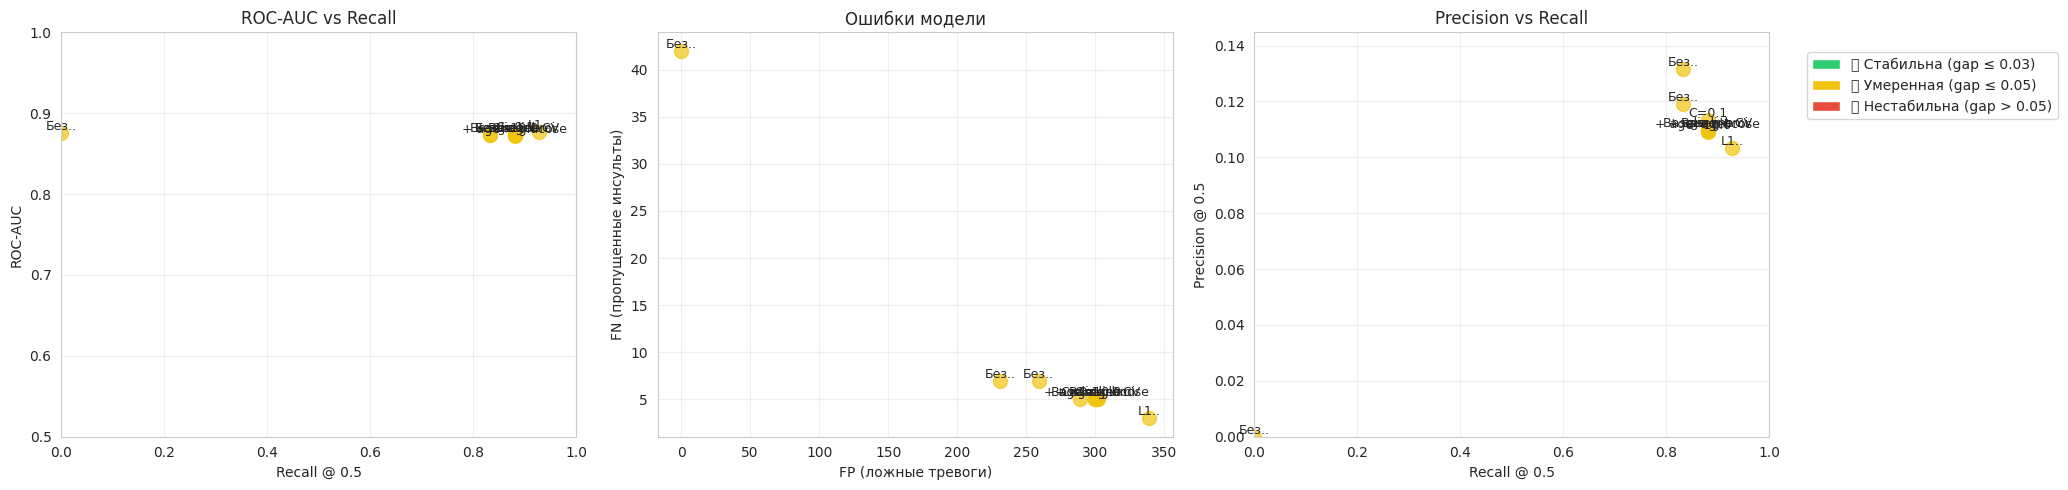


📊 АВТОМАТИЧЕСКИЕ ВЫВОДЫ ПО СРАВНЕНИЮ
🏆 Лучшая ROC-AUC: L1 регуляризация (AUC=0.8772)
🏆 Лучший Recall: L1 регуляризация (Recall=0.9286, FN=3)
🏆 Лучший F1: Без marriage_risk (F1=0.2273)
🏆 Лучшая Precision: Без marriage_risk (Precision=0.1316)


In [15]:
# 4.2 ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ЭКСПЕРИМЕНТОВ

save_path = os.path.join(PLOTS_PATH, 'experiments_comparison.png') if SAVE_PLOTS else None
plot_experiments_comparison(comparison_df, save_path=save_path)

In [16]:
# 4.3 ВЫБОР ЛУЧШЕЙ МОДЕЛИ

best_model_row, best_model_idx = select_best_model(
    comparison_df,
    primary_metric=SELECTION_PRIMARY_METRIC,
    secondary_metric=SELECTION_SECONDARY_METRIC,
    min_recall=SELECTION_MIN_RECALL,
    require_stable=SELECTION_REQUIRE_STABLE,
    force_experiment=FORCE_BEST_EXPERIMENT
)

if best_model_row is None:
    raise ValueError("❌ Не удалось выбрать лучшую модель.")

⚠️ Нет стабильных моделей (stability != ✅)
   Расширяем поиск на 🟡 модели...
🏆 АВТОМАТИЧЕСКИЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ
Первичная: auc_roc | Вторичная: FN_05 | Мин. Recall: 0.7
Требовать стабильность: True

✅ Выбрана: L1 регуляризация
   ROC-AUC: 0.8772 | Recall@0.5: 0.9286 | FN: 3
   Стабильность: 🟡 (gap_auc = -0.0462)


In [17]:
# 4.4 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ

print("\n" + "="*60)
print("📊 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ")
print("="*60)

# Функция для безопасного получения лучшей модели
def get_best_by_metric(df, metric, ascending=False):
    idx = df[metric].idxmax() if not ascending else df[metric].idxmin()
    return df.loc[idx]

# По ROC-AUC
best_auc = get_best_by_metric(comparison_df, 'auc_roc')
print(f"\n🏆 По ROC-AUC:")
print(f"   {best_auc['experiment']} ({best_auc.get('stability', '?')})")
print(f"   AUC={best_auc['auc_roc']:.4f}, Recall={best_auc['recall_05']:.4f}, FN={best_auc['FN_05']:.0f}")

# По Recall@0.5
best_rec = get_best_by_metric(comparison_df, 'recall_05')
print(f"\n🏆 По Recall@0.5:")
print(f"   {best_rec['experiment']} ({best_rec.get('stability', '?')})")
print(f"   Recall={best_rec['recall_05']:.4f}, AUC={best_rec['auc_roc']:.4f}, FN={best_rec['FN_05']:.0f}")

# По F1@0.5
best_f1 = get_best_by_metric(comparison_df, 'f1_05')
print(f"\n🏆 По F1@0.5:")
print(f"   {best_f1['experiment']} ({best_f1.get('stability', '?')})")
print(f"   F1={best_f1['f1_05']:.4f}, AUC={best_f1['auc_roc']:.4f}, Recall={best_f1['recall_05']:.4f}")

# По Precision@0.5
best_prec = get_best_by_metric(comparison_df, 'precision_05')
print(f"\n🏆 По Precision@0.5:")
print(f"   {best_prec['experiment']} ({best_prec.get('stability', '?')})")
print(f"   Precision={best_prec['precision_05']:.4f}, AUC={best_prec['auc_roc']:.4f}, Recall={best_prec['recall_05']:.4f}")

# По минимуму FN
best_fn = get_best_by_metric(comparison_df, 'FN_05', ascending=True)
print(f"\n🏆 По минимуму FN (пропущено):")
print(f"   {best_fn['experiment']} ({best_fn.get('stability', '?')})")
print(f"   FN={best_fn['FN_05']:.0f}, Recall={best_fn['recall_05']:.4f}, AUC={best_fn['auc_roc']:.4f}")

# ТОП-3 по основной метрике
print(f"\n📋 ТОП-3 ПО {SELECTION_PRIMARY_METRIC.upper()}:")
top3_cols = ['experiment', SELECTION_PRIMARY_METRIC, 'recall_05', 'precision_05', 'FN_05', 'stability']
top3 = comparison_df.nlargest(3, SELECTION_PRIMARY_METRIC)[top3_cols]
display(top3.round(4))

print("="*60)


📊 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ

🏆 По ROC-AUC:
   L1 регуляризация (🟡)
   AUC=0.8772, Recall=0.9286, FN=3

🏆 По Recall@0.5:
   L1 регуляризация (🟡)
   Recall=0.9286, AUC=0.8772, FN=3

🏆 По F1@0.5:
   Без marriage_risk (🟡)
   F1=0.2273, AUC=0.8735, Recall=0.8333

🏆 По Precision@0.5:
   Без marriage_risk (🟡)
   Precision=0.1316, AUC=0.8735, Recall=0.8333

🏆 По минимуму FN (пропущено):
   L1 регуляризация (🟡)
   FN=3, Recall=0.9286, AUC=0.8772

📋 ТОП-3 ПО AUC_ROC:


,experiment,auc_roc,recall_05,precision_05,FN_05,stability
5,L1 регуляризация,0.8772,0.9286,0.1032,3.0,🟡
2,Без балансировки,0.8755,0.0000,0.0000,42.0,🟡
3,C=0.1,0.8743,0.8810,0.1135,5.0,🟡


# БЛОК 5. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ

In [18]:
# 5.1 ИНИЦИАЛИЗАЦИЯ И МЕТРИКИ ПРИ ВСЕХ ПОРОГАХ

best_experiment_name = best_model_row['experiment']

# Находим трансформации и параметры этого эксперимента
best_transform = None
best_params = DEFAULT_MODEL_PARAMS.copy()

for exp_name, param_changes, transform_rules, _ in EXPERIMENTS_TO_RUN:
    if exp_name == best_experiment_name:
        best_transform = transform_rules
        best_params.update(param_changes)
        break

# Применяем трансформации к train и val
X_train_best, X_val_best = apply_transforms(X_train, X_val, best_transform)

# Берём уже обученную модель
best_model = all_models[best_experiment_name]

print("="*60)
print(f"📦 АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: {best_experiment_name}")
print("="*60)

# -----------------------------------------------------------------------------
# МЕТРИКИ ПРИ ВСЕХ ПОРОГАХ
# -----------------------------------------------------------------------------
df_thresh_best = all_thresholds[best_experiment_name]

# Ключевые пороги
threshold_05 = 0.5
threshold_f1 = best_model_row['best_threshold_f1']
threshold_youden = best_model_row.get('youden_threshold')

# Находим ближайший порог к Youden в таблице
closest_youden_threshold = None
if threshold_youden is not None:
    closest_youden_idx = (df_thresh_best['threshold'] - threshold_youden).abs().idxmin()
    closest_youden_threshold = df_thresh_best.loc[closest_youden_idx, 'threshold']

print(f"\n🔑 КЛЮЧЕВЫЕ ПОРОГИ:")
print(f"   Стандартный (0.5):           {threshold_05:.2f}")
print(f"   Оптимальный по F1:           {threshold_f1:.2f}")
if threshold_youden is not None:
    print(f"   Оптимальный по Youden's J:   {threshold_youden:.2f} (в таблице: {closest_youden_threshold:.2f})")

# Подсветка ключевых порогов в таблице
def highlight_key_thresholds(row):
    if abs(row['threshold'] - threshold_05) < 0.01:
        return ['background-color: #a8e6cf'] * len(row)   # зелёный
    elif abs(row['threshold'] - threshold_f1) < 0.01:
        return ['background-color: #ffb347'] * len(row)   # оранжевый
    elif closest_youden_threshold is not None and abs(row['threshold'] - closest_youden_threshold) < 0.01:
        return ['background-color: #74b9ff'] * len(row)   # насыщенный голубой
    return [''] * len(row)

print(f"\n📊 ДЕТАЛЬНЫЕ МЕТРИКИ ПО ПОРОГАМ:")
styled_df = df_thresh_best.style.apply(highlight_key_thresholds, axis=1)
display(styled_df.format(precision=4))

print("\n🎨 ЛЕГЕНДА:")
print("   🟢 Зелёный     — стандартный порог 0.5")
print("   🟠 Оранжевый   — оптимальный по F1")
if threshold_youden is not None:
    print("   🔵 Голубой     — оптимальный по Youden's J")

# Сравнение ключевых порогов
print("\n" + "="*60)
print("📋 СРАВНЕНИЕ КЛЮЧЕВЫХ ПОРОГОВ")
print("="*60)

key_rows = []
thresholds_to_show = [(0.5, '0.5'), (threshold_f1, 'Best F1')]
if threshold_youden is not None:
    thresholds_to_show.append((threshold_youden, 'Youden'))

for thresh_val, thresh_name in thresholds_to_show:
    closest_idx = (df_thresh_best['threshold'] - thresh_val).abs().idxmin()
    row = df_thresh_best.loc[closest_idx].copy()
    row['threshold_type'] = thresh_name
    key_rows.append(row)

comparison_key = pd.DataFrame(key_rows)[
    ['threshold_type', 'threshold', 'precision', 'recall', 'f1', 'mcc', 'FN', 'FP', 'TP', 'TN']
]
display(comparison_key.round(4))

print("="*60)

📦 АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: L1 регуляризация

🔑 КЛЮЧЕВЫЕ ПОРОГИ:
   Стандартный (0.5):           0.50
   Оптимальный по F1:           0.90
   Оптимальный по Youden's J:   0.82 (в таблице: 0.80)

📊 ДЕТАЛЬНЫЕ МЕТРИКИ ПО ПОРОГАМ:


,threshold,precision,recall,f1,mcc,TP,FN,FP,TN,pred_positives
0,0.1000,0.0660,1.0000,0.1239,0.1543,42,0,594,335,636
1,0.1500,0.0707,1.0000,0.1321,0.1694,42,0,552,377,594
2,0.2000,0.0766,1.0000,0.1424,0.1868,42,0,506,423,548
3,0.2500,0.0802,1.0000,0.1484,0.1964,42,0,482,447,524
4,0.3000,0.0873,1.0000,0.1606,0.2146,42,0,439,490,481
5,0.3500,0.0919,1.0000,0.1683,0.2255,42,0,415,514,457
6,0.4000,0.0972,1.0000,0.1772,0.2375,42,0,390,539,432
7,0.4500,0.1015,0.9762,0.1839,0.2416,41,1,363,566,404
8,0.5000,0.1032,0.9286,0.1857,0.2352,39,3,339,590,378
9,0.5500,0.1017,0.8571,0.1818,0.2176,36,6,318,611,354



🎨 ЛЕГЕНДА:
   🟢 Зелёный     — стандартный порог 0.5
   🟠 Оранжевый   — оптимальный по F1
   🔵 Голубой     — оптимальный по Youden's J

📋 СРАВНЕНИЕ КЛЮЧЕВЫХ ПОРОГОВ


,threshold_type,threshold,precision,recall,f1,mcc,FN,FP,TP,TN
8,0.5,0.5,0.1032,0.9286,0.1857,0.2352,3.0,339.0,39.0,590.0
16,Best F1,0.9,0.1926,0.6190,0.2938,0.2950,16.0,109.0,26.0,820.0
14,Youden,0.8,0.1633,0.7619,0.2689,0.2967,10.0,164.0,32.0,765.0



✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/threshold_analysis_L1_регуляризация.png


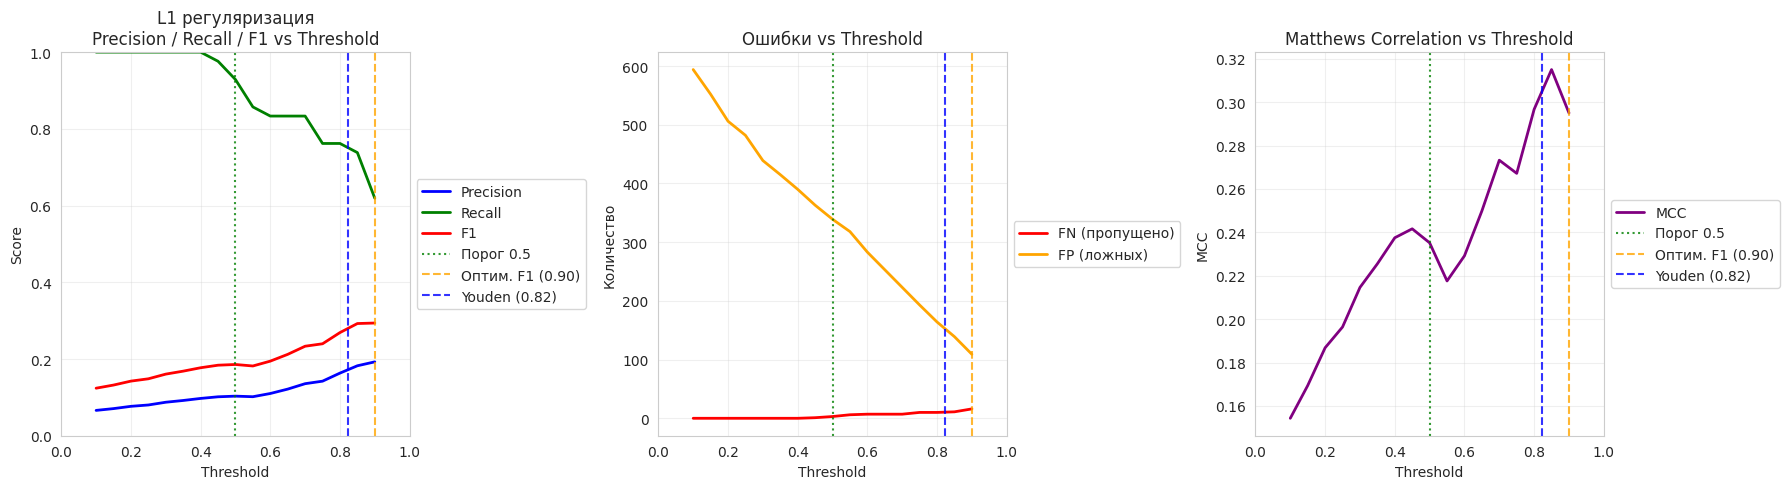

In [19]:
# 5.2 ВИЗУАЛИЗАЦИЯ МЕТРИК ПО ПОРОГАМ

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Precision, Recall, F1 vs Threshold
ax1 = axes[0]
ax1.plot(df_thresh_best['threshold'], df_thresh_best['precision'], 'b-', label='Precision', linewidth=2)
ax1.plot(df_thresh_best['threshold'], df_thresh_best['recall'], 'g-', label='Recall', linewidth=2)
ax1.plot(df_thresh_best['threshold'], df_thresh_best['f1'], 'r-', label='F1', linewidth=2)
ax1.axvline(x=0.5, color='green', linestyle=':', alpha=0.8, label='Порог 0.5')
ax1.axvline(x=best_model_row['best_threshold_f1'], color='orange', linestyle='--', alpha=0.8,
            label=f"Оптим. F1 ({best_model_row['best_threshold_f1']:.2f})")
ax1.axvline(x=best_model_row['youden_threshold'], color='blue', linestyle='--', alpha=0.8,
            label=f"Youden ({best_model_row['youden_threshold']:.2f})")
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title(f'{best_experiment_name}\nPrecision / Recall / F1 vs Threshold')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# График 2: FN и FP vs Threshold
ax2 = axes[1]
ax2.plot(df_thresh_best['threshold'], df_thresh_best['FN'], 'r-', label='FN (пропущено)', linewidth=2)
ax2.plot(df_thresh_best['threshold'], df_thresh_best['FP'], 'orange', label='FP (ложных)', linewidth=2)
ax2.axvline(x=0.5, color='green', linestyle=':', alpha=0.8)
ax2.axvline(x=best_model_row['best_threshold_f1'], color='orange', linestyle='--', alpha=0.8)
ax2.axvline(x=best_model_row['youden_threshold'], color='blue', linestyle='--', alpha=0.8)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Количество')
ax2.set_title('Ошибки vs Threshold')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

# График 3: MCC vs Threshold
ax3 = axes[2]
ax3.plot(df_thresh_best['threshold'], df_thresh_best['mcc'], 'purple', label='MCC', linewidth=2)
ax3.axvline(x=0.5, color='green', linestyle=':', alpha=0.8, label='Порог 0.5')
ax3.axvline(x=best_model_row['best_threshold_f1'], color='orange', linestyle='--', alpha=0.8,
            label=f"Оптим. F1 ({best_model_row['best_threshold_f1']:.2f})")
ax3.axvline(x=best_model_row['youden_threshold'], color='blue', linestyle='--', alpha=0.8,
            label=f"Youden ({best_model_row['youden_threshold']:.2f})")
ax3.set_xlabel('Threshold')
ax3.set_ylabel('MCC')
ax3.set_title('Matthews Correlation vs Threshold')
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 1)

plt.tight_layout()

# Сохранение
if SAVE_PLOTS:
    save_path = os.path.join(PLOTS_PATH, f'threshold_analysis_{best_experiment_name.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ График сохранён: {save_path}")

plt.show()

✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/confusion_matrices_L1_регуляризация.png


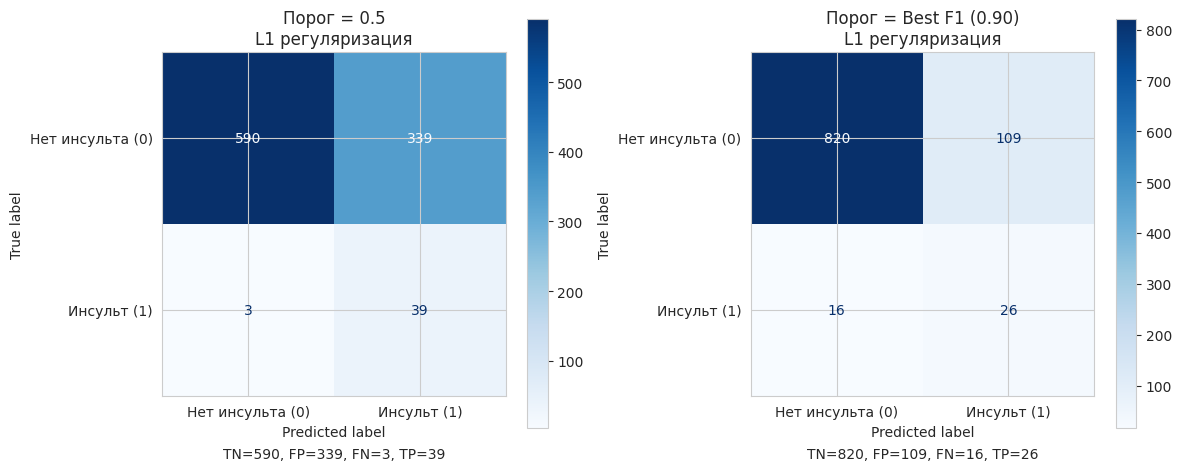


📊 СРАВНЕНИЕ ПОРОГОВ (VALIDATION)


,Порог,Precision,Recall,F1,MCC,FN,FP,TP,TN
0,0.5,0.1032,0.9286,0.1857,0.2352,3,339,39,590
1,Best F1 (0.90),0.1926,0.6190,0.2938,0.2950,16,109,26,820


In [20]:
# 5.3 МАТРИЦЫ ОШИБОК (ПОРОГ 0.5 И ОПТИМАЛЬНЫЙ F1)

# Предсказания (используем уже готовые переменные из 5.1)
y_val_proba_best = best_model.predict_proba(X_val_best)[:, 1]

# Пороги для сравнения
thresholds_to_show = [
    (0.5, '0.5'),
    (best_model_row['best_threshold_f1'], f"Best F1 ({best_model_row['best_threshold_f1']:.2f})")
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (thresh, thresh_name) in zip(axes, thresholds_to_show):
    y_pred = (y_val_proba_best >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет инсульта (0)', 'Инсульт (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'Порог = {thresh_name}\n{best_experiment_name}')

    TN, FP, FN, TP = cm.ravel()
    ax.text(0.5, -0.15, f'TN={TN}, FP={FP}, FN={FN}, TP={TP}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10)

plt.tight_layout()

# Сохранение
if SAVE_PLOTS:
    save_path = os.path.join(PLOTS_PATH, f'confusion_matrices_{best_experiment_name.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ График сохранён: {save_path}")

plt.show()

# Сравнение метрик при разных порогах
print("\n" + "="*60)
print("📊 СРАВНЕНИЕ ПОРОГОВ (VALIDATION)")
print("="*60)

comparison_data = []
for thresh, thresh_name in thresholds_to_show:
    y_pred = (y_val_proba_best >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    TN, FP, FN, TP = cm.ravel()

    comparison_data.append({
        'Порог': thresh_name,
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1': f1_score(y_val, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_val, y_pred),
        'FN': FN,
        'FP': FP,
        'TP': TP,
        'TN': TN
    })

comparison_df_thresh = pd.DataFrame(comparison_data)
display(comparison_df_thresh.round(4))

print("="*60)

✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/roc_pr_curves_L1_регуляризация.png


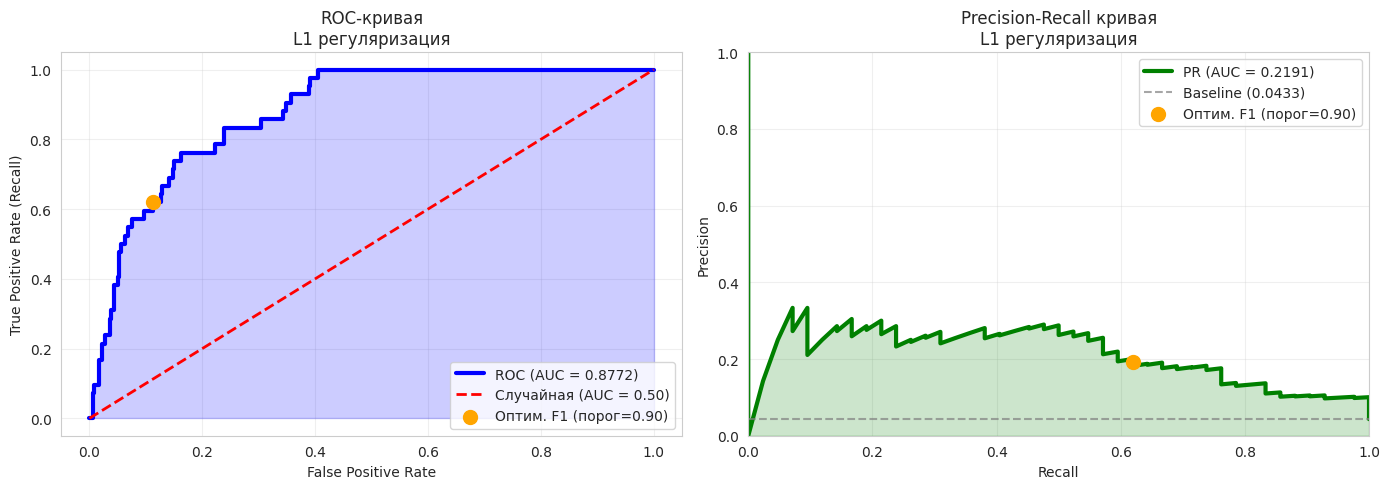


📌 КООРДИНАТЫ ПРИ ОПТИМАЛЬНОМ ПОРОГЕ F1 (0.90)
   ROC: FPR = 0.1119, TPR = 0.6190
   PR:  Precision = 0.1926, Recall = 0.6190


In [21]:
# 5.4 ROC И PR КРИВЫЕ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
fpr, tpr, roc_thresholds = roc_curve(y_val, y_val_proba_best)
auc_roc = best_model_row['auc_roc']

# Находим точку, ближайшую к оптимальному порогу по F1
opt_thresh = best_model_row['best_threshold_f1']
idx_opt = np.argmin(np.abs(roc_thresholds - opt_thresh))
fpr_opt, tpr_opt = fpr[idx_opt], tpr[idx_opt]

ax1 = axes[0]
ax1.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC (AUC = {auc_roc:.4f})')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Случайная (AUC = 0.50)')
ax1.scatter(fpr_opt, tpr_opt, color='orange', s=100, zorder=5,
            label=f'Оптим. F1 (порог={opt_thresh:.2f})')
ax1.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title(f'ROC-кривая\n{best_experiment_name}')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Precision-Recall кривая
precisions, recalls, pr_thresholds = precision_recall_curve(y_val, y_val_proba_best)
auc_pr = best_model_row['auc_pr']

# Находим точку для оптимального порога на PR-кривой
# PR-кривая имеет на 1 элемент больше, thresholds короче
pr_thresholds_extended = np.append(pr_thresholds, 1.0)
idx_pr_opt = np.argmin(np.abs(pr_thresholds_extended - opt_thresh))
prec_opt, rec_opt = precisions[idx_pr_opt], recalls[idx_pr_opt]

ax2 = axes[1]
ax2.plot(recalls, precisions, 'g-', linewidth=3, label=f'PR (AUC = {auc_pr:.4f})')
ax2.axhline(y=y_val.mean(), color='gray', linestyle='--', alpha=0.7,
            label=f'Baseline ({y_val.mean():.4f})')
ax2.scatter(rec_opt, prec_opt, color='orange', s=100, zorder=5,
            label=f'Оптим. F1 (порог={opt_thresh:.2f})')
ax2.fill_between(recalls, precisions, alpha=0.2, color='green')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_title(f'Precision-Recall кривая\n{best_experiment_name}')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Сохранение
if SAVE_PLOTS:
    save_path = os.path.join(PLOTS_PATH, f'roc_pr_curves_{best_experiment_name.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ График сохранён: {save_path}")

plt.show()

# Координаты ключевой точки
print("\n" + "="*60)
print(f"📌 КООРДИНАТЫ ПРИ ОПТИМАЛЬНОМ ПОРОГЕ F1 ({opt_thresh:.2f})")
print("="*60)
print(f"   ROC: FPR = {fpr_opt:.4f}, TPR = {tpr_opt:.4f}")
print(f"   PR:  Precision = {prec_opt:.4f}, Recall = {rec_opt:.4f}")
print("="*60)

# БЛОК 6. СТАТИСТИЧЕСКИЙ АНАЛИЗ

📊 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ


,Признак,Коэффициент,Odds_Ratio,p-value,Значим (p<0.05),Интерпретация
0,const,-4.1216,0.0162,0.0000,✅ Да,Базовый шанс (интерсепт)
1,age,1.9770,7.2211,0.0000,✅ Да,↑ Повышает шанс в 7.22 раз (CI > 1)
2,avg_glucose_level,0.1213,1.1290,0.0493,✅ Да,↑ Повышает шанс в 1.13 раз (CI > 1)
3,bmi,0.1073,1.1132,0.4475,❌ Нет,Статистически незначим
4,cardio_risk,0.5564,1.7444,0.0078,✅ Да,↑ Повышает шанс в 1.74 раз (CI > 1)
5,marriage_risk_senior_married,-0.9904,0.3714,0.0083,✅ Да,↓ Понижает шанс в 2.69 раз (CI < 1)
6,marriage_risk_senior_unmarried,-0.3960,0.6730,0.4351,❌ Нет,Статистически незначим



📋 ПОЛНАЯ ТАБЛИЦА (с доверительными интервалами):


,Признак,Коэффициент,Std.Error,p-value,CI_lower,CI_upper,Odds_Ratio,OR_CI_lower,OR_CI_upper
0,const,-4.1216,0.1967,0.0000,-4.5071,-3.7360,0.0162,0.0110,0.0238
1,age,1.9770,0.2931,0.0000,1.4026,2.5514,7.2211,4.0658,12.8253
2,avg_glucose_level,0.1213,0.0617,0.0493,0.0004,0.2422,1.1290,1.0004,1.2741
3,bmi,0.1073,0.1412,0.4475,-0.1695,0.3840,1.1132,0.8441,1.4682
4,cardio_risk,0.5564,0.2092,0.0078,0.1464,0.9664,1.7444,1.1576,2.6285
5,marriage_risk_senior_married,-0.9904,0.3754,0.0083,-1.7262,-0.2547,0.3714,0.1780,0.7752
6,marriage_risk_senior_unmarried,-0.3960,0.5074,0.4351,-1.3904,0.5985,0.6730,0.2490,1.8193



🔑 ЗНАЧИМЫЕ ПРИЗНАКИ
✅ Статистически значимые признаки (4):
   ↑ age: OR=7.221, p=0.0000
   ↑ avg_glucose_level: OR=1.129, p=0.0493
   ↑ cardio_risk: OR=1.744, p=0.0078
   ↓ marriage_risk_senior_married: OR=0.371, p=0.0083

✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/odds_ratio_L1_регуляризация.png


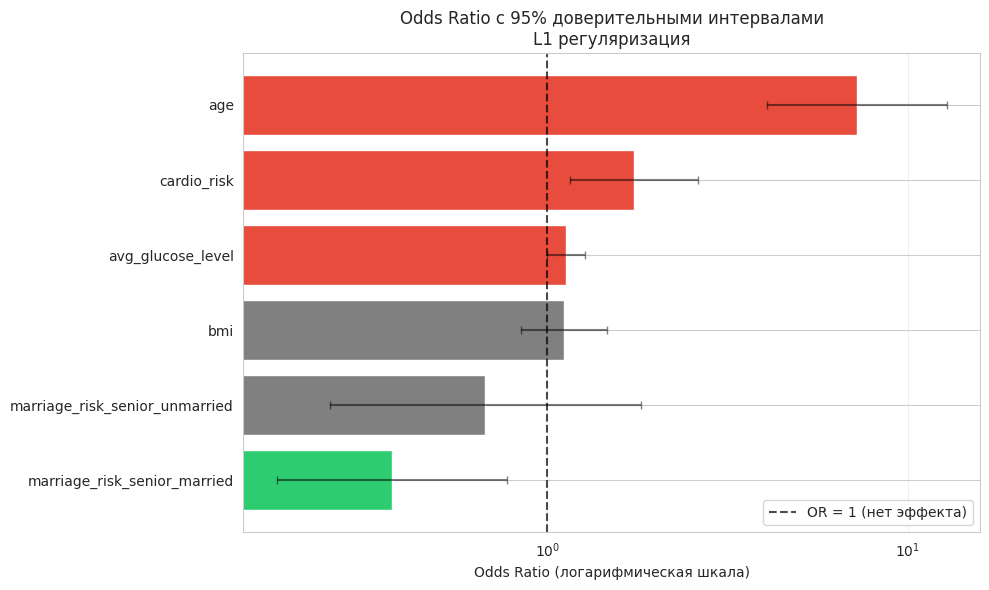


🎨 ЛЕГЕНДА:
   🔴 Красный  — значимо повышает риск (CI > 1)
   🟢 Зелёный  — значимо понижает риск (CI < 1)
   🟡 Жёлтый   — эффект есть, но CI включает 1
   ⚫ Серый    — статистически не значим


In [22]:
# 6.1 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ

# Проверка, что модель — логистическая регрессия
if not isinstance(best_model, LogisticRegression):
    print("⚠️ Статистический анализ доступен только для LogisticRegression.")
    print(f"   Текущая модель: {type(best_model).__name__}")
else:
    # Добавляем константу для statsmodels
    X_train_sm = sm.add_constant(X_train_best)

    # Обучаем модель через statsmodels
    logit_model = sm.Logit(y_train, X_train_sm)
    result = logit_model.fit(disp=0)

    # Таблица с коэффициентами
    coef_table = pd.DataFrame({
        'Признак': ['const'] + list(X_train_best.columns),
        'Коэффициент': result.params.values,
        'Std.Error': result.bse.values,
        'z-value': result.tvalues.values,
        'p-value': result.pvalues.values,
        'CI_lower': result.conf_int()[0].values,
        'CI_upper': result.conf_int()[1].values
    })

    # Odds Ratio и доверительные интервалы
    coef_table['Odds_Ratio'] = np.exp(coef_table['Коэффициент'])
    coef_table['OR_CI_lower'] = np.exp(coef_table['CI_lower'])
    coef_table['OR_CI_upper'] = np.exp(coef_table['CI_upper'])

    # Значимость
    coef_table['Значим (p<0.05)'] = coef_table['p-value'].apply(
        lambda p: '✅ Да' if p < 0.05 else '❌ Нет'
    )

    # Интерпретация
    def interpret_coef(row):
        if row['Признак'] == 'const':
            return 'Базовый шанс (интерсепт)'
        if row['p-value'] >= 0.05:
            return 'Статистически незначим'
        if row['Odds_Ratio'] > 1:
            if row['OR_CI_lower'] > 1:
                return f'↑ Повышает шанс в {row["Odds_Ratio"]:.2f} раз (CI > 1)'
            else:
                return f'↑ Повышает шанс в {row["Odds_Ratio"]:.2f} раз (CI включает 1)'
        else:
            if row['OR_CI_upper'] < 1:
                return f'↓ Понижает шанс в {1/row["Odds_Ratio"]:.2f} раз (CI < 1)'
            else:
                return f'↓ Понижает шанс в {1/row["Odds_Ratio"]:.2f} раз (CI включает 1)'

    coef_table['Интерпретация'] = coef_table.apply(interpret_coef, axis=1)

    print("="*60)
    print("📊 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ")
    print("="*60)

    # Краткая таблица
    display_cols = ['Признак', 'Коэффициент', 'Odds_Ratio', 'p-value', 'Значим (p<0.05)', 'Интерпретация']
    display(coef_table[display_cols].round(4))

    # Полная таблица с доверительными интервалами
    print("\n📋 ПОЛНАЯ ТАБЛИЦА (с доверительными интервалами):")
    full_cols = ['Признак', 'Коэффициент', 'Std.Error', 'p-value', 'CI_lower', 'CI_upper', 'Odds_Ratio', 'OR_CI_lower', 'OR_CI_upper']
    display(coef_table[full_cols].round(4))

    # Ключевые выводы
    print("\n" + "="*60)
    print("🔑 ЗНАЧИМЫЕ ПРИЗНАКИ")
    print("="*60)

    significant = coef_table[coef_table['p-value'] < 0.05]
    significant = significant[significant['Признак'] != 'const']

    if len(significant) == 0:
        print("⚠️ Нет статистически значимых признаков (все p-value ≥ 0.05)")
    else:
        print(f"✅ Статистически значимые признаки ({len(significant)}):")
        for _, row in significant.iterrows():
            direction = "↑" if row['Odds_Ratio'] > 1 else "↓"
            print(f"   {direction} {row['Признак']}: OR={row['Odds_Ratio']:.3f}, p={row['p-value']:.4f}")

    # -------------------------------------------------------------------------
    # ВИЗУАЛИЗАЦИЯ ODDS RATIO (FOREST PLOT)
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    # Только признаки (без const)
    plot_data = coef_table[coef_table['Признак'] != 'const'].copy()
    plot_data = plot_data.sort_values('Odds_Ratio')

    colors = []
    for _, row in plot_data.iterrows():
        if row['p-value'] >= 0.05:
            colors.append('gray')
        elif row['Odds_Ratio'] > 1:
            colors.append('#e74c3c' if row['OR_CI_lower'] > 1 else '#f1c40f')
        else:
            colors.append('#2ecc71' if row['OR_CI_upper'] < 1 else '#f1c40f')

    ax.barh(plot_data['Признак'], plot_data['Odds_Ratio'], color=colors)
    ax.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='OR = 1 (нет эффекта)')

    # Добавляем CI как error bars
    ax.errorbar(plot_data['Odds_Ratio'], plot_data['Признак'],
                xerr=[plot_data['Odds_Ratio'] - plot_data['OR_CI_lower'],
                      plot_data['OR_CI_upper'] - plot_data['Odds_Ratio']],
                fmt='none', ecolor='black', capsize=3, alpha=0.5)

    ax.set_xlabel('Odds Ratio (логарифмическая шкала)')
    ax.set_title(f'Odds Ratio с 95% доверительными интервалами\n{best_experiment_name}')
    ax.set_xscale('log')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()

    # Сохранение
    if SAVE_PLOTS:
        save_path = os.path.join(PLOTS_PATH, f'odds_ratio_{best_experiment_name.replace(" ", "_")}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ График сохранён: {save_path}")

    plt.show()

    print("\n🎨 ЛЕГЕНДА:")
    print("   🔴 Красный  — значимо повышает риск (CI > 1)")
    print("   🟢 Зелёный  — значимо понижает риск (CI < 1)")
    print("   🟡 Жёлтый   — эффект есть, но CI включает 1")
    print("   ⚫ Серый    — статистически не значим")
    print("="*60)

# БЛОК 7. ТЕСТИРОВАНИЕ МОДЕЛИ

In [23]:
# 7.1 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА TRAIN+VAL

# Объединение train и val
X_train_full = pd.concat([X_train_best, X_val_best])
y_train_full = pd.concat([y_train, y_val])

print("="*60)
print("🔄 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА TRAIN+VAL")
print("="*60)
print(f"Train+Val: {X_train_full.shape[0]} примеров, {X_train_full.shape[1]} признаков")
print(f"Параметры: {best_params}")

# Финальное обучение
final_model = LogisticRegression(**best_params)
final_model.fit(X_train_full, y_train_full)

print("✅ Финальная модель обучена")

# Применяем трансформации к тесту
if best_transform is not None:
    _, X_test_best = apply_transforms(X_train, X_test, best_transform)
    print(f"✓ Трансформации применены к тесту: {X_test_best.shape}")
else:
    X_test_best = X_test.copy()
    print("✓ Трансформации не применялись (best_transform = None)")

print("="*60)

🔄 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА TRAIN+VAL
Train+Val: 3882 примеров, 6 признаков
Параметры: {'class_weight': 'balanced', 'random_state': 42, 'max_iter': 1000, 'solver': 'saga', 'penalty': 'l1', 'C': 1.0}
✅ Финальная модель обучена
✓ Трансформации не применялись (best_transform = None)


📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ

🔹 ПОРОГ: 0.5
   ROC-AUC:     0.8587
   PR-AUC:      0.2327
   Recall:      0.9286
   Precision:   0.1080
   F1-score:    0.1935
   MCC:         0.2450
   Матрица:     TN=607, FP=322, FN=3, TP=39

🔹 ПОРОГ: Best F1 (0.90)
   ROC-AUC:     0.8587
   PR-AUC:      0.2327
   Recall:      0.5714
   Precision:   0.1589
   F1-score:    0.2487
   MCC:         0.2440
   Матрица:     TN=802, FP=127, FN=18, TP=24

📈 СРАВНЕНИЕ VAL vs TEST (порог 0.5)
   ROC-AUC:  0.8772 → 0.8587  (Δ = -0.0185)
   Recall:   0.9286 → 0.9286  (Δ = +0.0000)
   F1:       0.1857 → 0.1935  (Δ = +0.0078)
   FN:       3 → 3  (Δ = +0)

📊 Вердикт: ✅ Модель стабильна (ΔAUC = -0.0185)

✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/test_confusion_matrices_L1_регуляризация.png


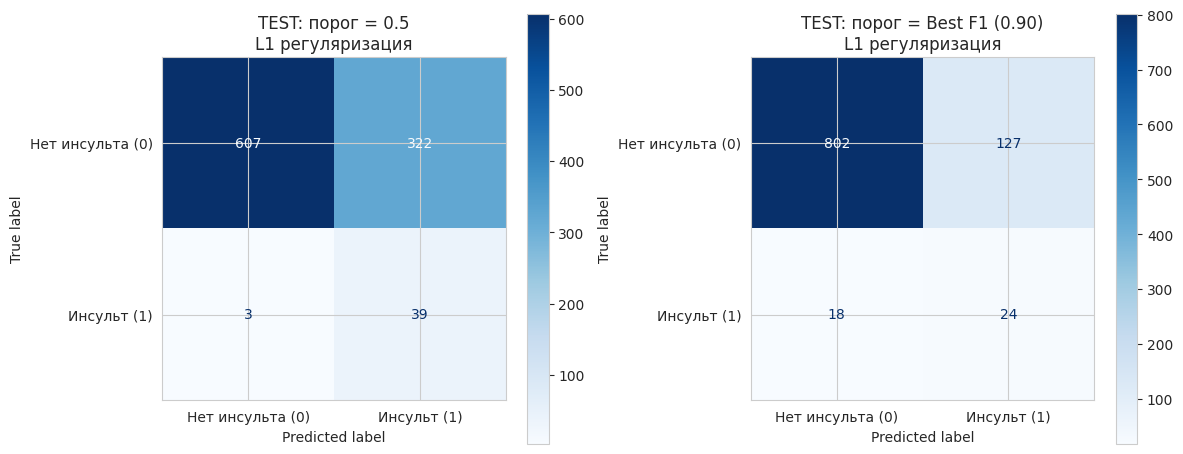

In [24]:
# 7.2 ТЕСТИРОВАНИЕ ФИНАЛЬНОЙ МОДЕЛИ

# Предсказания
y_test_proba = final_model.predict_proba(X_test_best)[:, 1]
test_proba_full = final_model.predict_proba(X_test_best)  # ← добавить

# Пороги для оценки
thresholds_test = [
    (0.5, '0.5'),
    (best_model_row['best_threshold_f1'], f"Best F1 ({best_model_row['best_threshold_f1']:.2f})")
]

print("="*60)
print("📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

results_test = []

for thresh, thresh_name in thresholds_test:
    y_test_pred = (y_test_proba >= thresh).astype(int)

    # Метрики
    test_auc = roc_auc_score(y_test, y_test_proba)
    test_pr_auc = average_precision_score(y_test, y_test_proba)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_mcc = matthews_corrcoef(y_test, y_test_pred)

    cm_test = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm_test.ravel()

    results_test.append({
        'Порог': thresh_name,
        'AUC': test_auc,
        'PR-AUC': test_pr_auc,
        'Recall': test_recall,
        'Precision': test_precision,
        'F1': test_f1,
        'MCC': test_mcc,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP
    })

    print(f"\n🔹 ПОРОГ: {thresh_name}")
    print(f"   ROC-AUC:     {test_auc:.4f}")
    print(f"   PR-AUC:      {test_pr_auc:.4f}")
    print(f"   Recall:      {test_recall:.4f}")
    print(f"   Precision:   {test_precision:.4f}")
    print(f"   F1-score:    {test_f1:.4f}")
    print(f"   MCC:         {test_mcc:.4f}")
    print(f"   Матрица:     TN={TN}, FP={FP}, FN={FN}, TP={TP}")

# Сохраняем метрики для порога 0.5 для использования в других блоках
test_metrics = results_test[0]

# Сравнение Val vs Test
print("\n" + "="*60)
print("📈 СРАВНЕНИЕ VAL vs TEST (порог 0.5)")
print("="*60)
print(f"   ROC-AUC:  {best_model_row['auc_roc']:.4f} → {test_metrics['AUC']:.4f}  (Δ = {test_metrics['AUC'] - best_model_row['auc_roc']:+.4f})")
print(f"   Recall:   {best_model_row['recall_05']:.4f} → {test_metrics['Recall']:.4f}  (Δ = {test_metrics['Recall'] - best_model_row['recall_05']:+.4f})")
print(f"   F1:       {best_model_row['f1_05']:.4f} → {test_metrics['F1']:.4f}  (Δ = {test_metrics['F1'] - best_model_row['f1_05']:+.4f})")
print(f"   FN:       {best_model_row['FN_05']:.0f} → {test_metrics['FN']}  (Δ = {test_metrics['FN'] - best_model_row['FN_05']:+.0f})")

# Оценка стабильности
gap_auc = test_metrics['AUC'] - best_model_row['auc_roc']
if abs(gap_auc) <= SELECTION_GAP_THRESHOLD:
    stability_verdict = "✅ Модель стабильна"
elif abs(gap_auc) <= SELECTION_WARNING_THRESHOLD:
    stability_verdict = "🟡 Умеренное падение"
else:
    stability_verdict = "🔴 Значительное падение"

print(f"\n📊 Вердикт: {stability_verdict} (ΔAUC = {gap_auc:+.4f})")

# Визуализация матриц ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (thresh, thresh_name) in zip(axes, thresholds_test):
    y_test_pred = (y_test_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_test_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет инсульта (0)', 'Инсульт (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'TEST: порог = {thresh_name}\n{best_experiment_name}')

plt.tight_layout()

# Сохранение
if SAVE_PLOTS:
    save_path = os.path.join(PLOTS_PATH, f'test_confusion_matrices_{best_experiment_name.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ График сохранён: {save_path}")

plt.show()

print("="*60)

In [25]:
# 7.3 СРАВНЕНИЕ VALIDATION vs TEST И ИТОГОВЫЙ ВЕРДИКТ

comparison_val_test = pd.DataFrame({
    'Выборка': ['Validation', 'Test'],
    'ROC-AUC': [best_model_row['auc_roc'], test_metrics['AUC']],
    'PR-AUC': [best_model_row['auc_pr'], test_metrics['PR-AUC']],
    'Recall': [best_model_row['recall_05'], test_metrics['Recall']],
    'Precision': [best_model_row['precision_05'], test_metrics['Precision']],
    'F1': [best_model_row['f1_05'], test_metrics['F1']],
    'MCC': [best_model_row['mcc_05'], test_metrics['MCC']],
    'FN': [best_model_row['FN_05'], test_metrics['FN']],
    'FP': [best_model_row['FP_05'], test_metrics['FP']]
})

print("="*60)
print("📊 СРАВНЕНИЕ VALIDATION vs TEST (порог 0.5)")
print("="*60)
display(comparison_val_test.round(4))

# Сохранение таблицы
if SAVE_EXPERIMENTS_TABLE:
    table_path = os.path.join(REPORTS_PATH, 'val_test_comparison.csv')
    comparison_val_test.to_csv(table_path, index=False)
    print(f"\n✓ Таблица сохранена: {table_path}")

# -----------------------------------------------------------------------------
# ПРОВЕРКА СТАБИЛЬНОСТИ
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔍 ПРОВЕРКА СТАБИЛЬНОСТИ МОДЕЛИ")
print("="*60)

# Используем пороги из настроек
gap_auc_threshold = SELECTION_GAP_THRESHOLD
gap_warning_threshold = SELECTION_WARNING_THRESHOLD
gap_recall_threshold = 0.10  # для Recall порог обычно выше

auc_gap = best_model_row['auc_roc'] - test_metrics['AUC']
recall_gap = best_model_row['recall_05'] - test_metrics['Recall']
f1_gap = best_model_row['f1_05'] - test_metrics['F1']

# Оценка стабильности по AUC
if abs(auc_gap) <= gap_auc_threshold:
    auc_status, auc_text = "✅", f"отличная (gap = {auc_gap:+.4f})"
elif abs(auc_gap) <= gap_warning_threshold:
    auc_status, auc_text = "🟡", f"умеренная (gap = {auc_gap:+.4f})"
else:
    auc_status, auc_text = "🔴", f"критичная (gap = {auc_gap:+.4f})"

# Оценка стабильности по Recall
if abs(recall_gap) <= gap_recall_threshold:
    recall_status, recall_text = "✅", f"отличная (gap = {recall_gap:+.4f})"
else:
    recall_status, recall_text = "🔴", f"большой gap = {recall_gap:+.4f}"

print(f"{auc_status} ROC-AUC:  {auc_text}")
print(f"{recall_status} Recall:   {recall_text}")
print(f"   F1:       gap = {f1_gap:+.4f}")

# Итоговый вердикт
if auc_status == "✅" and recall_status == "✅":
    stability = "✅ МОДЕЛЬ СТАБИЛЬНА"
    verdict = "Хорошо обобщается на тестовые данные, переобучения нет."
elif auc_status == "🔴" or recall_status == "🔴":
    stability = "🔴 ОБНАРУЖЕНО ПЕРЕОБУЧЕНИЕ"
    verdict = "Значительное падение метрик на тесте. Рекомендуется упростить модель или увеличить регуляризацию."
else:
    stability = "🟡 УМЕРЕННАЯ СТАБИЛЬНОСТЬ"
    verdict = "Небольшое падение метрик. Можно попробовать увеличить регуляризацию."

print("\n" + "="*60)
print(f"🏆 ИТОГОВЫЙ ВЕРДИКТ: {stability}")
print("="*60)
print(f"   {verdict}")
print("="*60)

📊 СРАВНЕНИЕ VALIDATION vs TEST (порог 0.5)


,Выборка,ROC-AUC,PR-AUC,Recall,Precision,F1,MCC,FN,FP
0,Validation,0.8772,0.2191,0.9286,0.1032,0.1857,0.2352,3.0,339.0
1,Test,0.8587,0.2327,0.9286,0.1080,0.1935,0.2450,3.0,322.0



✓ Таблица сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/val_test_comparison.csv

🔍 ПРОВЕРКА СТАБИЛЬНОСТИ МОДЕЛИ
✅ ROC-AUC:  отличная (gap = +0.0185)
✅ Recall:   отличная (gap = +0.0000)
   F1:       gap = -0.0078

🏆 ИТОГОВЫЙ ВЕРДИКТ: ✅ МОДЕЛЬ СТАБИЛЬНА
   Хорошо обобщается на тестовые данные, переобучения нет.


# БЛОК 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ

In [26]:
# 8. ФИНАЛЬНОЕ СОХРАНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ

print("="*60)
print("💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

# Создание папки для финальной модели
final_model_path = os.path.join(MODELS_PATH, 'LogisticRegression_Final')
os.makedirs(final_model_path, exist_ok=True)

# -----------------------------------------------------------------------------
# 1. Модель
# -----------------------------------------------------------------------------
model_file = os.path.join(final_model_path, 'model.pkl')
joblib.dump(final_model, model_file)
print(f"✓ Модель: {model_file}")

# -----------------------------------------------------------------------------
# 2. Метаданные
# -----------------------------------------------------------------------------
metadata_final = {
    'model_type': 'LogisticRegression',
    'experiment_name': best_experiment_name,
    'params': best_params,
    'transform_rules': best_transform,
    'feature_columns': list(X_train_best.columns),
    'thresholds': {
        'default': 0.5,
        'best_f1': float(best_model_row['best_threshold_f1']),
        'youden': float(best_model_row.get('youden_threshold', 0.5))
    },
    'val_metrics': {
        'auc_roc': float(best_model_row['auc_roc']),
        'auc_pr': float(best_model_row['auc_pr']),
        'recall_05': float(best_model_row['recall_05']),
        'precision_05': float(best_model_row['precision_05']),
        'f1_05': float(best_model_row['f1_05']),
        'mcc_05': float(best_model_row['mcc_05']),
        'FN_05': int(best_model_row['FN_05']),
        'FP_05': int(best_model_row['FP_05'])
    },
    'test_metrics': {
        'auc_roc': float(test_metrics['AUC']),
        'auc_pr': float(test_metrics['PR-AUC']),
        'recall': float(test_metrics['Recall']),
        'precision': float(test_metrics['Precision']),
        'f1': float(test_metrics['F1']),
        'mcc': float(test_metrics['MCC']),
        'FN': int(test_metrics['FN']),
        'FP': int(test_metrics['FP']),
        'TP': int(test_metrics['TP']),
        'TN': int(test_metrics['TN'])
    },
    'stability': {
        'auc_gap': float(auc_gap),
        'recall_gap': float(recall_gap),
        'verdict': stability
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_file = os.path.join(final_model_path, 'metadata.json')
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata_final, f, indent=2, ensure_ascii=False)
print(f"✓ Метаданные: {metadata_file}")

# -----------------------------------------------------------------------------
# 3. Таблицы
# -----------------------------------------------------------------------------
# Сводная таблица экспериментов
experiments_file = os.path.join(final_model_path, 'experiments_comparison.csv')
comparison_df.to_csv(experiments_file, index=False)
print(f"✓ Сравнение экспериментов: {experiments_file}")

# Метрики по порогам для лучшей модели
thresholds_file = os.path.join(final_model_path, 'threshold_analysis.csv')
df_thresh_best.to_csv(thresholds_file, index=False)
print(f"✓ Таблица порогов: {thresholds_file}")

# Сравнение Val/Test
valtest_file = os.path.join(final_model_path, 'val_test_comparison.csv')
comparison_val_test.to_csv(valtest_file, index=False)
print(f"✓ Сравнение Val/Test: {valtest_file}")

# Коэффициенты со статистикой (если есть)
if 'coef_table' in dir() and coef_table is not None:
    coef_file = os.path.join(final_model_path, 'coefficients_stats.csv')
    coef_table.to_csv(coef_file, index=False)
    print(f"✓ Коэффициенты: {coef_file}")

# -----------------------------------------------------------------------------
# 4. Предсказания
# -----------------------------------------------------------------------------
opt_thresh = best_model_row['best_threshold_f1']

# Тест (используем переменные из 7.2)
y_test_pred_05 = (y_test_proba >= 0.5).astype(int)
y_test_pred_opt = (y_test_proba >= opt_thresh).astype(int)

test_predictions = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba': y_test_proba,
    'y_pred_05': y_test_pred_05,
    'y_pred_opt': y_test_pred_opt,
    'proba_class_0': test_proba_full[:, 0],
    'proba_class_1': test_proba_full[:, 1]
})
pred_file = os.path.join(final_model_path, 'test_predictions.csv')
test_predictions.to_csv(pred_file, index=False)
print(f"✓ Тестовые предсказания: {pred_file}")
print(f"   Инсультов (0.5): {test_predictions['y_pred_05'].sum()}, (оптим.): {test_predictions['y_pred_opt'].sum()}")

# Валидация (используем уже вычисленные предсказания из 5.3)
y_val_pred_05 = (y_val_proba_best >= 0.5).astype(int)
y_val_pred_opt = (y_val_proba_best >= opt_thresh).astype(int)

val_predictions = pd.DataFrame({
    'y_true': y_val.values,
    'y_proba': y_val_proba_best,
    'y_pred_05': y_val_pred_05,
    'y_pred_opt': y_val_pred_opt
})
val_pred_file = os.path.join(final_model_path, 'val_predictions.csv')
val_predictions.to_csv(val_pred_file, index=False)
print(f"✓ Валидационные предсказания: {val_pred_file}")

print("="*60)
print("✅ ВСЕ РЕЗУЛЬТАТЫ СОХРАНЕНЫ")
print("="*60)

💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✓ Модель: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/model.pkl
✓ Метаданные: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/metadata.json
✓ Сравнение экспериментов: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/experiments_comparison.csv
✓ Таблица порогов: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/threshold_analysis.csv
✓ Сравнение Val/Test: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/val_test_comparison.csv
✓ Коэффициенты: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/coefficients_stats.csv
✓ Тестовые предсказания: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/test_predictions.csv
   Инсультов (0.5): 361, (оптим.): 151
✓ Валидационные предсказания: /content/drive/MyDrive/ml_learning/datasets/stroke

# БЛОК 9. ИТОГОВЫЙ ОТЧЁТ

In [27]:
# 9. ИТОГОВЫЙ ОТЧЁТ

print("\n" + "="*80)
print(f"🎉 ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ: {PROJECT_NAME.upper()}")
print("="*80)

print("\n📊 ЛУЧШАЯ МОДЕЛЬ:")
print(f"   Эксперимент:      {best_experiment_name}")
print(f"   ROC-AUC (val):    {best_model_row['auc_roc']:.4f}")
print(f"   ROC-AUC (test):   {test_metrics['AUC']:.4f}")
print(f"   PR-AUC (test):    {test_metrics['PR-AUC']:.4f}")
print(f"   Recall (test):    {test_metrics['Recall']:.4f}")
print(f"   Precision (test): {test_metrics['Precision']:.4f}")
print(f"   F1 (test):        {test_metrics['F1']:.4f}")
print(f"   MCC (test):       {test_metrics['MCC']:.4f}")

print("\n🎯 ОПТИМАЛЬНЫЕ ПОРОГИ:")
print(f"   Стандартный (0.5):   0.50")
print(f"   По F1:               {best_model_row['best_threshold_f1']:.2f}")
print(f"   По Youden's J:       {best_model_row.get('youden_threshold', 0.5):.2f}")

print("\n🔍 СТАБИЛЬНОСТЬ:")
print(f"   Δ AUC (val - test):  {auc_gap:+.4f}")
print(f"   Δ Recall:            {recall_gap:+.4f}")
print(f"   Вердикт:             {stability}")

print("\n📋 ЗНАЧИМЫЕ ПРИЗНАКИ (p < 0.05):")
if 'coef_table' in dir() and coef_table is not None:
    significant = coef_table[coef_table['p-value'] < 0.05]
    significant = significant[significant['Признак'] != 'const']
    if len(significant) > 0:
        for _, row in significant.iterrows():
            direction = "↑" if row['Odds_Ratio'] > 1 else "↓"
            print(f"   {direction} {row['Признак']}: OR={row['Odds_Ratio']:.3f}, p={row['p-value']:.4f}")
    else:
        print("   Нет статистически значимых признаков")
else:
    print("   Статистический анализ не выполнялся")

print("\n📁 СОХРАНЁННЫЕ ФАЙЛЫ:")
print(f"   {final_model_path}/")
print("   ├── model.pkl")
print("   ├── metadata.json")
print("   ├── test_predictions.csv")
print("   ├── val_predictions.csv")
print("   ├── experiments_comparison.csv")
print("   ├── threshold_analysis.csv")
print("   ├── val_test_comparison.csv")
if 'coef_table' in dir() and coef_table is not None:
    print("   └── coefficients_stats.csv")

print("\n" + "="*80)
print("✅ ШАБЛОН ЗАВЕРШИЛ РАБОТУ УСПЕШНО")
print("="*80)


🎉 ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ: STROKE

📊 ЛУЧШАЯ МОДЕЛЬ:
   Эксперимент:      L1 регуляризация
   ROC-AUC (val):    0.8772
   ROC-AUC (test):   0.8587
   PR-AUC (test):    0.2327
   Recall (test):    0.9286
   Precision (test): 0.1080
   F1 (test):        0.1935
   MCC (test):       0.2450

🎯 ОПТИМАЛЬНЫЕ ПОРОГИ:
   Стандартный (0.5):   0.50
   По F1:               0.90
   По Youden's J:       0.82

🔍 СТАБИЛЬНОСТЬ:
   Δ AUC (val - test):  +0.0185
   Δ Recall:            +0.0000
   Вердикт:             ✅ МОДЕЛЬ СТАБИЛЬНА

📋 ЗНАЧИМЫЕ ПРИЗНАКИ (p < 0.05):
   ↑ age: OR=7.221, p=0.0000
   ↑ avg_glucose_level: OR=1.129, p=0.0493
   ↑ cardio_risk: OR=1.744, p=0.0078
   ↓ marriage_risk_senior_married: OR=0.371, p=0.0083

📁 СОХРАНЁННЫЕ ФАЙЛЫ:
   /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/
   ├── model.pkl
   ├── metadata.json
   ├── test_predictions.csv
   ├── val_predictions.csv
   ├── experiments_comparison.csv
   ├── threshold_analysis.csv
   ├── val_test